# Financial inclusion 2011–2024: what the Global Findex 2025 shows

How has access to financial services changed since 2011 — and did usage, resilience and equality keep up?

This analysis uses the [Global Findex Database 2025](https://www.worldbank.org/en/publication/globalfindex) (World Bank), the standard global survey of how adults save, borrow, pay and manage financial risk: 162 economies, five survey waves (2011, 2014, 2017, 2021, 2024), ~1,000 respondents per economy per wave.

**Questions:**
1. **Access** — how far has account ownership spread, globally and by region?
2. **Usage** — do people actually use accounts: digital payments, saving, borrowing, dormancy?
3. **Resilience** — can people raise emergency funds when a shock hits?
4. **Equality** — what happened to the gender gap and the income gap?

The analysis started life as the empirical chapter of my bachelor's thesis. This is the rebuilt version: every aggregate is computed on a fixed country panel and validated against the World Bank's own published aggregates (section 2.3). Section 7 lists what the audit of the original version found.

## 1. Data

### 1.1 Load and structure

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 12)

df = pd.read_csv('../01_Data/GlobalFindexDatabase2025.csv', low_memory=False)
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')
df[['countrynewwb', 'codewb', 'year', 'pop_adult', 'regionwb24_hi',
    'incomegroupwb24', 'group', 'group2', 'account_t_d']].head(3)

8,564 rows x 437 columns


,countrynewwb,codewb,year,pop_adult,regionwb24_hi,incomegroupwb24,group,group2,account_t_d
0,Afghanistan,AFG,2011,14575546.0,South Asia (excluding high income),Low income,all,all,0.090050
1,Albania,ALB,2011,2281010.0,Europe & Central Asia (excluding high income),Upper middle income,all,all,0.282681
2,Algeria,DZA,2011,26251587.0,Middle East & North Africa (excluding high inc...,Lower middle income,all,all,0.332861


The file is in long format: one row per **economy × survey wave × population group**. The `group`/`group2` columns hold the disaggregations — `all` (total adult population), men/women, richest 60%/poorest 40%, age and education splits. Indicator values are population shares between 0 and 1.

Two structural facts matter for everything that follows:

1. **The file mixes country rows with the World Bank's own aggregate rows** (`world`, `Developing economies`, regions, income groups). Aggregates carry no `pop_adult` and no region code. They must be separated — but they are also a gift: a built-in ground truth to validate my own aggregation against.
2. **Every calculation must pick one `group` slice.** A filter that forgets this averages the total population together with every demographic subgroup of the same country — each weighted by full country population.

In [2]:
# Separate country rows from the World Bank's official aggregate rows
countries = df[df['regionwb24_hi'].notna()].copy()
official = df[df['regionwb24_hi'].isna()].copy()

print('Economies:', countries['countrynewwb'].nunique())
print('Official aggregate entities:', sorted(official['countrynewwb'].unique()))

Economies: 162
Official aggregate entities: ['Developing economies', 'East Asia & Pacific (excluding high income)', 'Europe & Central Asia (excluding high income)', 'High income', 'Latin America & Caribbean (excluding high income)', 'Low income', 'Lower middle income', 'Middle East & North Africa (excluding high income)', 'South Asia', 'Sub-Saharan Africa (excluding high income)', 'Upper middle income', 'world']


### 1.2 Wave harmonization

The file labels 16 economies with `year == 2022`: their 2021-round fieldwork was delayed by COVID-19 restrictions. The World Bank counts them as part of the 2021 wave, and so do I — this is done once, before anything else is computed, so no later step can see an inconsistent state.

In [3]:
delayed = countries.loc[countries['year'] == 2022, 'countrynewwb'].unique()
print(f'{len(delayed)} economies surveyed in 2022, merged into the 2021 wave:')
print(', '.join(sorted(delayed)))

for frame in (countries, official):
    frame['year'] = frame['year'].replace(2022, 2021)

YEARS = [2011, 2014, 2017, 2021, 2024]

16 economies surveyed in 2022, merged into the 2021 wave:
Azerbaijan, Botswana, Chad, Comoros, Congo, Dem. Rep., Eswatini, Ethiopia, Gambia, The, Guatemala, Lesotho, Madagascar, Mauritania, Mexico, Niger, Viet Nam, Yemen, Rep.


## 2. Methodology

### 2.1 Balanced country panel

Survey coverage changes between waves (139–146 economies per wave). If aggregates are computed over "whatever was surveyed that year", part of any trend is just the country mix changing — this is not hypothetical, section 7 shows it flipping the sign of two trends in the original version. All headline series below therefore use a **balanced panel: only economies present in all five waves**.

In [4]:
c_all = countries[countries['group'] == 'all']
waves_per_country = c_all.groupby('countrynewwb')['year'].nunique()
panel = waves_per_country[waves_per_country == 5].index

pan_all = c_all[c_all['countrynewwb'].isin(panel)]          # panel, total population rows
pan_dev = pan_all[pan_all['incomegroupwb24'] != 'High income']   # developing economies
pan_grp = countries[countries['countrynewwb'].isin(panel)]  # panel, all group rows (for gender/income)

coverage = (pan_all[pan_all['year'] == 2024]['pop_adult'].sum()
            / c_all[c_all['year'] == 2024]['pop_adult'].sum())
print(f'Panel: {len(panel)} economies ({pan_dev["countrynewwb"].nunique()} developing)')
print(f'Adult-population coverage of the panel, 2024: {coverage:.1%} of all surveyed economies')

Panel: 117 economies (77 developing)
Adult-population coverage of the panel, 2024: 96.5% of all surveyed economies


117 economies covering 96.5% of the surveyed adult population — dropping the in-and-out economies costs almost no coverage but buys a consistent composition.

### 2.2 Population-weighted aggregation

Averaging country shares directly would let Iceland count as much as India. Aggregates are therefore weighted by adult population (`pop_adult`), matching World Bank practice:

In [5]:
def wmean(d, col, weight='pop_adult'):
    """Population-weighted mean of `col` over the rows of `d` that have both value and weight."""
    sub = d.dropna(subset=[col, weight])
    return np.nan if sub.empty else np.average(sub[col], weights=sub[weight])

def series(frame, col, years=YEARS):
    """Weighted mean of `col` per year -> pd.Series (in percent)."""
    return pd.Series({y: wmean(frame[frame['year'] == y], col) for y in years}).dropna() * 100

def official_series(entity, col, years=YEARS):
    """The World Bank's own published aggregate for comparison (in percent)."""
    d = official[(official['countrynewwb'] == entity) & (official['group'] == 'all')]
    return pd.Series({y: d.loc[d['year'] == y, col].squeeze() for y in years}).astype(float).dropna() * 100

### 2.3 Validation against official aggregates

Before trusting the pipeline, I check it on the headline indicator. The two series are built differently — the World Bank imputes values for economies missing from a wave, my panel simply excludes them — so they should agree closely but not exactly:

In [6]:
val = pd.DataFrame({
    'Balanced panel (this analysis)': series(pan_all, 'account_t_d'),
    'Official world aggregate': official_series('world', 'account_t_d'),
}).round(1)
val['difference (pp)'] = (val.iloc[:, 0] - val.iloc[:, 1]).round(1)
val

,Balanced panel (this analysis),Official world aggregate,difference (pp)
2011,51.4,50.6,0.8
2014,62.8,61.7,1.1
2017,70.5,69.3,1.2
2021,75.3,73.8,1.5
2024,78.9,78.7,0.2


Maximum deviation 1.5 pp, and the direction is explainable: economies missing from some waves are disproportionately poorer, so the official (imputed) world number sits slightly below the panel. Every chart below carries the official aggregate as hollow markers, so the two sources stay visible side by side.

## 3. Access

### 3.1 Account ownership

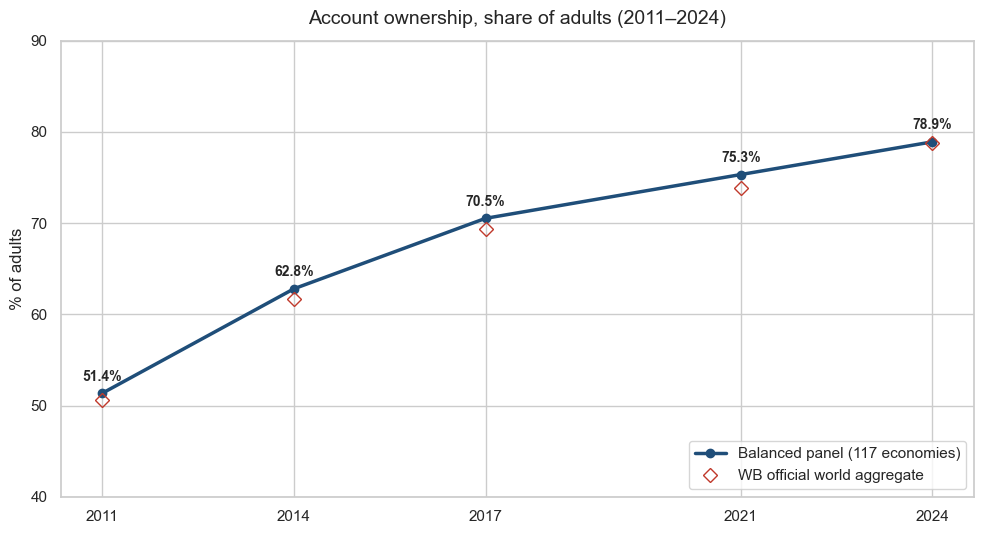

In [7]:
FIG_DIR = '../03_Outputs/figures'
import os; os.makedirs(FIG_DIR, exist_ok=True)

acc_panel = series(pan_all, 'account_t_d')
acc_off = official_series('world', 'account_t_d')

plt.figure(figsize=(10, 5.5))
plt.plot(acc_panel.index, acc_panel, marker='o', lw=2.5, color='#1f4e79',
         label='Balanced panel (117 economies)')
plt.plot(acc_off.index, acc_off, ls='none', marker='D', ms=7, mfc='none',
         color='#c0392b', label='WB official world aggregate')
for x, y in acc_panel.items():
    plt.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 9),
                 ha='center', fontweight='bold', fontsize=10)
plt.title('Account ownership, share of adults (2011–2024)', fontsize=14, pad=12)
plt.ylabel('% of adults')
plt.ylim(40, 90)
plt.xticks(YEARS)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_account_ownership.png', bbox_inches='tight')
plt.show()

Account ownership rose from about half of adults in 2011 to **79% in 2024** — one of the fastest expansions of access to a formal service on record. Growth has slowed as the easy gains were exhausted: +11 pp in 2011–2014, +4 pp in 2021–2024.

### 3.2 Regional trajectories

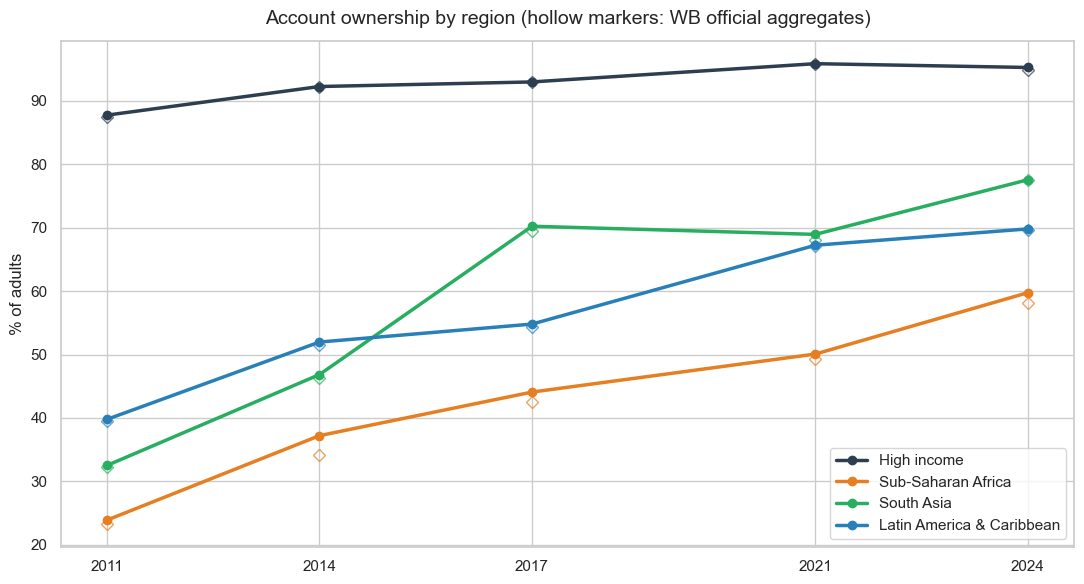

In [8]:
REGIONS = {
    'High income': ('High income', '#2c3e50'),
    'Sub-Saharan Africa (excluding high income)': ('Sub-Saharan Africa (excluding high income)', '#e67e22'),
    'South Asia (excluding high income)': ('South Asia', '#27ae60'),
    'Latin America & Caribbean (excluding high income)': ('Latin America & Caribbean (excluding high income)', '#2980b9'),
}
SHORT = {'High income': 'High income',
         'Sub-Saharan Africa (excluding high income)': 'Sub-Saharan Africa',
         'South Asia (excluding high income)': 'South Asia',
         'Latin America & Caribbean (excluding high income)': 'Latin America & Caribbean'}

plt.figure(figsize=(11, 6))
for reg, (agg_name, color) in REGIONS.items():
    s = series(pan_all[pan_all['regionwb24_hi'] == reg], 'account_t_d')
    o = official_series(agg_name, 'account_t_d')
    plt.plot(s.index, s, marker='o', lw=2.5, color=color, label=SHORT[reg])
    plt.plot(o.index, o, ls='none', marker='D', ms=6, mfc='none', color=color, alpha=0.7)
plt.title('Account ownership by region (hollow markers: WB official aggregates)', fontsize=14, pad=12)
plt.ylabel('% of adults')
plt.xticks(YEARS)
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_regional_account.png', bbox_inches='tight')
plt.show()

Three different convergence stories: **South Asia** made the largest leap (33% → 78%, driven by India's account-opening programs), **Sub-Saharan Africa** more than doubled from the lowest base (24% → 60%), and **Latin America** climbed steadily to 70%. High-income economies are near saturation.

### 3.3 Mobile money — and a measurement trap

Mobile money accounts (M-Pesa-style services) are only surveyed in economies where such services operate. That makes the "global average" dangerously easy to get wrong: averaging only the surveyed economies produces a number dominated by Sub-Saharan Africa.

In [9]:
mm = pan_all.copy()
mm['mm_filled'] = mm['mobileaccount_t_d'].fillna(0)  # not surveyed => adoption ~ 0

trap = pd.DataFrame({
    'Naive mean (surveyed economies only)': series(pan_all, 'mobileaccount_t_d', [2014, 2017, 2021, 2024]),
    'Unsurveyed treated as zero': series(mm, 'mm_filled', [2014, 2017, 2021, 2024]),
    'WB official world aggregate': official_series('world', 'mobileaccount_t_d', [2014, 2017, 2021, 2024]),
}).round(1)
trap

,Naive mean (surveyed economies only),Unsurveyed treated as zero,WB official world aggregate
2014,3.9,2.1,2.1
2017,8.1,4.4,4.5
2021,18.1,10.4,10.5
2024,28.5,17.0,16.0


The naive average runs at almost **double** the official world aggregate (28.5% vs 16.0% in 2024). Treating not-surveyed economies as zero-adoption reproduces the official series almost exactly — which confirms that this is the assumption the World Bank itself effectively makes. The original version of this analysis fell into precisely this trap (section 7).

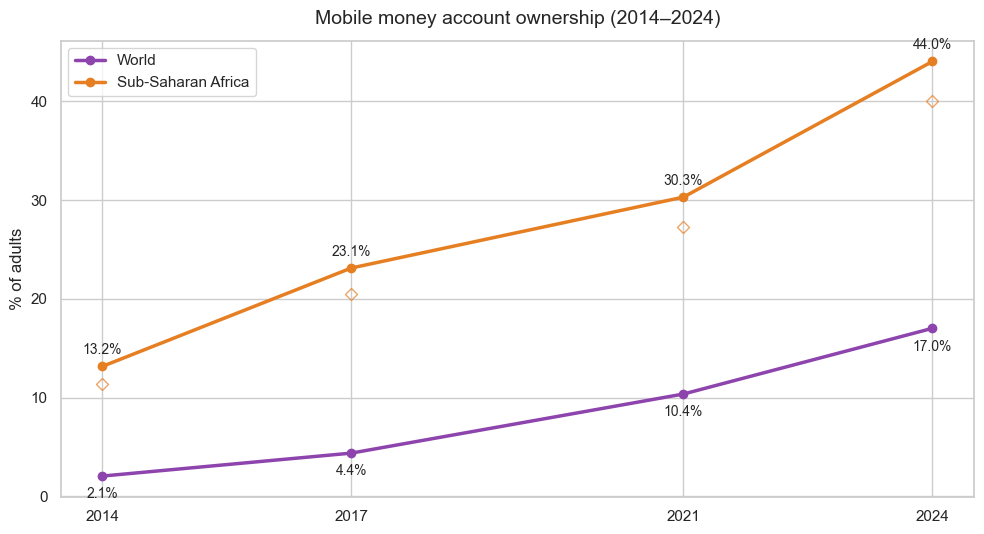

In [10]:
mm_world = series(mm, 'mm_filled', [2014, 2017, 2021, 2024])
mm_ssa = series(pan_all[pan_all['regionwb24_hi'] == 'Sub-Saharan Africa (excluding high income)'],
                'mobileaccount_t_d', [2014, 2017, 2021, 2024])
mm_ssa_off = official_series('Sub-Saharan Africa (excluding high income)', 'mobileaccount_t_d',
                             [2014, 2017, 2021, 2024])

plt.figure(figsize=(10, 5.5))
plt.plot(mm_world.index, mm_world, marker='o', lw=2.5, color='#8e44ad', label='World')
plt.plot(mm_ssa.index, mm_ssa, marker='o', lw=2.5, color='#e67e22', label='Sub-Saharan Africa')
plt.plot(mm_ssa_off.index, mm_ssa_off, ls='none', marker='D', ms=6, mfc='none', color='#e67e22', alpha=0.7)
for x, y in mm_world.items():
    plt.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, -16), ha='center', fontsize=10)
for x, y in mm_ssa.items():
    plt.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=10)
plt.title('Mobile money account ownership (2014–2024)', fontsize=14, pad=12)
plt.ylabel('% of adults')
plt.xticks([2014, 2017, 2021, 2024])
plt.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_mobile_money.png', bbox_inches='tight')
plt.show()

Mobile money was not measured in 2011 (the services barely existed at scale), so the series starts in 2014 rather than pretending a zero data point. Globally it reached 17% of adults by 2024; in Sub-Saharan Africa it is the backbone of financial inclusion at 44% — higher than bank-account-only ownership for much of the region.

## 4. Usage

### 4.1 Digital payments

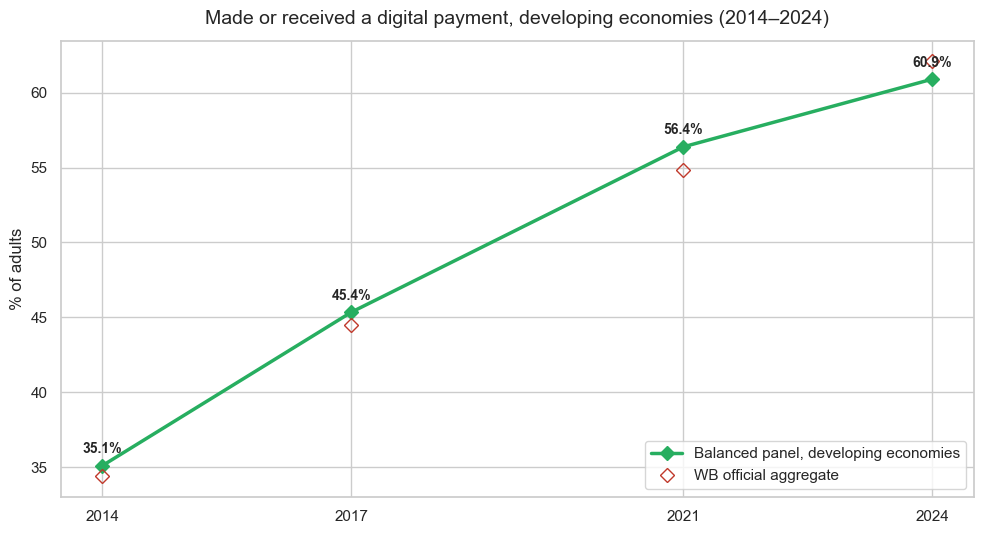

In [11]:
dp_dev = series(pan_dev, 'g20_any', [2014, 2017, 2021, 2024])
dp_off = official_series('Developing economies', 'g20_any', [2014, 2017, 2021, 2024])

plt.figure(figsize=(10, 5.5))
plt.plot(dp_dev.index, dp_dev, marker='D', ms=7, lw=2.5, color='#27ae60',
         label='Balanced panel, developing economies')
plt.plot(dp_off.index, dp_off, ls='none', marker='D', ms=7, mfc='none', color='#c0392b',
         label='WB official aggregate')
for x, y in dp_dev.items():
    plt.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 9),
                 ha='center', fontweight='bold', fontsize=10)
plt.title('Made or received a digital payment, developing economies (2014–2024)', fontsize=14, pad=12)
plt.ylabel('% of adults')
plt.xticks([2014, 2017, 2021, 2024])
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_digital_payments.png', bbox_inches='tight')
plt.show()

High-income panel economies with digital-payment data per wave:
year
2011     0
2014    40
2017    40
2021    40
2024     5


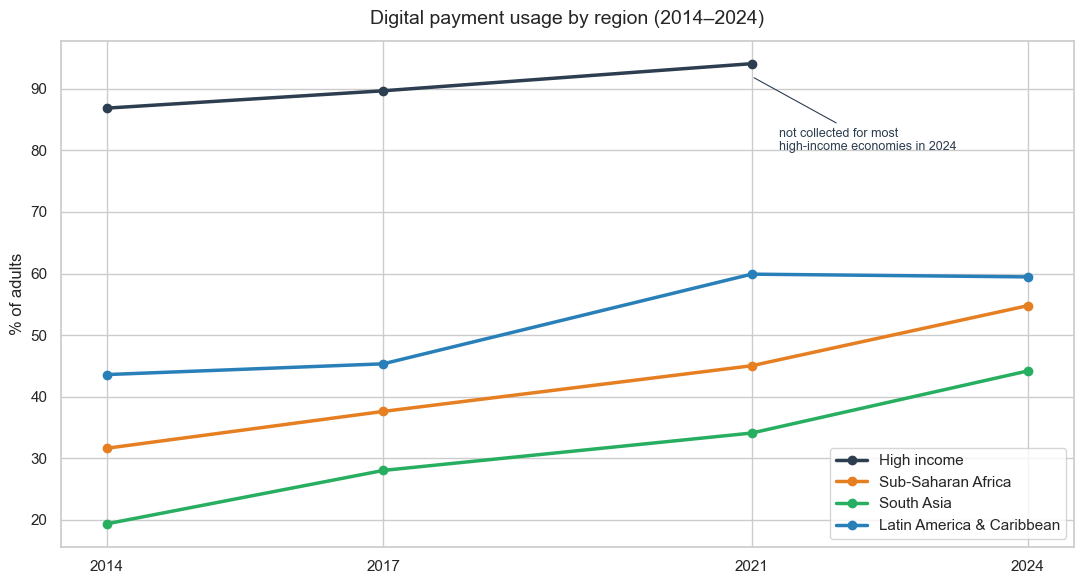

In [12]:
# Regional digital payments. High-income g20_any was collected for only a handful of
# high-income economies in the 2024 wave -> the line stops in 2021 instead of faking a trend.
hi_cov = pan_all[pan_all['incomegroupwb24'] == 'High income'].groupby('year')['g20_any'].count()
print('High-income panel economies with digital-payment data per wave:')
print(hi_cov.to_string())

plt.figure(figsize=(11, 6))
for reg, (agg_name, color) in REGIONS.items():
    d = pan_all[pan_all['regionwb24_hi'] == reg]
    yrs = [2014, 2017, 2021] if reg == 'High income' else [2014, 2017, 2021, 2024]
    s = series(d, 'g20_any', yrs)
    plt.plot(s.index, s, marker='o', lw=2.5, color=color, label=SHORT[reg])
plt.annotate('not collected for most\nhigh-income economies in 2024', xy=(2021, 92),
             xytext=(2021.3, 80), fontsize=9, color='#2c3e50',
             arrowprops=dict(arrowstyle='-', color='#2c3e50', lw=0.8))
plt.title('Digital payment usage by region (2014–2024)', fontsize=14, pad=12)
plt.ylabel('% of adults')
plt.xticks([2014, 2017, 2021, 2024])
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig5_regional_digital_payments.png', bbox_inches='tight')
plt.show()

Digital payments are the fastest-moving usage indicator: from 35% to 61% of adults in developing economies in a decade. Sub-Saharan Africa's curve rides on mobile money; South Asia's on public digital-payment infrastructure.

(The high-income line ends in 2021 because the 2024 wave collected this indicator for only 5 of 40 high-income panel economies — a data gap, not a behavioral change. The original version of this chart plotted those 5 economies as if they were the group and showed a spurious 20-point collapse.)

### 4.2 Saving and borrowing — the headline finding of Findex 2025

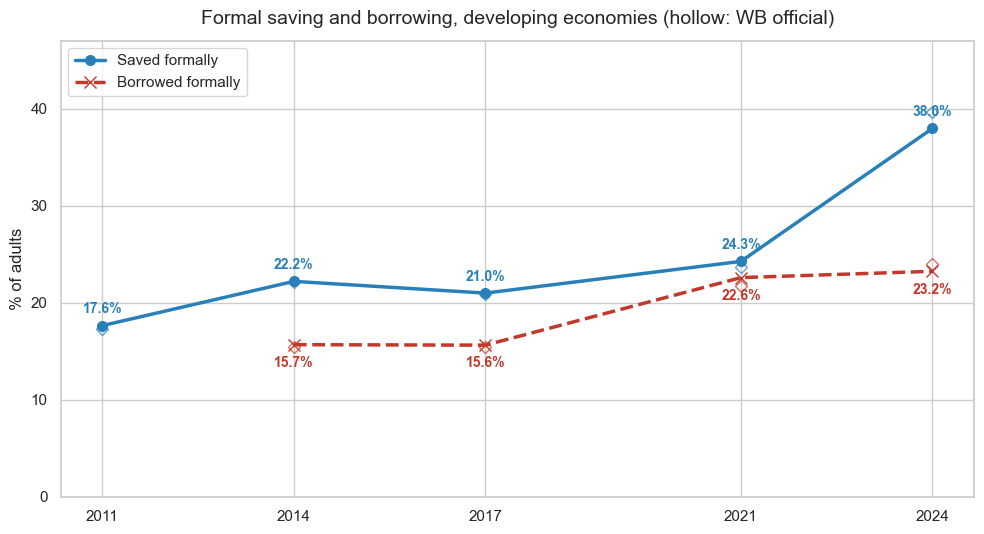

In [13]:
sav = series(pan_dev, 'fin17a_17a1_d')            # saved formally (incl. mobile money account)
bor = series(pan_dev, 'fin22a_22a1_22g_d', [2014, 2017, 2021, 2024])  # borrowed formally
sav_off = official_series('Developing economies', 'fin17a_17a1_d')
bor_off = official_series('Developing economies', 'fin22a_22a1_22g_d', [2014, 2017, 2021, 2024])

plt.figure(figsize=(10, 5.5))
plt.plot(sav.index, sav, marker='o', ms=7, lw=2.5, color='#2980b9', label='Saved formally')
plt.plot(bor.index, bor, marker='x', ms=8, lw=2.5, ls='--', color='#c0392b', label='Borrowed formally')
plt.plot(sav_off.index, sav_off, ls='none', marker='D', ms=6, mfc='none', color='#2980b9', alpha=0.7)
plt.plot(bor_off.index, bor_off, ls='none', marker='D', ms=6, mfc='none', color='#c0392b', alpha=0.7)
for x, y in sav.items():
    plt.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 9),
                 ha='center', color='#2980b9', fontweight='bold', fontsize=10)
for x, y in bor.items():
    plt.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, -16),
                 ha='center', color='#c0392b', fontweight='bold', fontsize=10)
plt.title('Formal saving and borrowing, developing economies (hollow: WB official)', fontsize=14, pad=12)
plt.ylabel('% of adults')
plt.ylim(0, 47)
plt.xticks(YEARS)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig6_saving_borrowing.png', bbox_inches='tight')
plt.show()

In [14]:
# What drove the savings jump? Decompose formal saving into "at a financial institution"
# vs the additional adults who saved via a mobile money account.
sav_fi = series(pan_dev, 'fin17a', [2021, 2024])
sav_total = series(pan_dev, 'fin17a_17a1_d', [2021, 2024])
decomp = pd.DataFrame({'Saved at financial institution': sav_fi,
                       'Saved formally incl. mobile money': sav_total})
decomp['Mobile money contribution (pp)'] = (decomp.iloc[:, 1] - decomp.iloc[:, 0]).round(1)
decomp.round(1)

,Saved at financial institution,Saved formally incl. mobile money,Mobile money contribution (pp)
2021,22.5,24.3,1.8
2024,33.7,38.0,4.3


Formal saving in developing economies **jumped from 24.3% to 38.0% of adults between 2021 and 2024** (+13.7 pp on the panel; the World Bank's official aggregate says +16 pp, to 40%) — the single largest wave-to-wave change in the Findex series and the flagship finding of the 2025 report. Mobile money accounts contribute about 4 pp of the 2024 level, with Sub-Saharan Africa the epicenter.

Formal borrowing, by contrast, moved slowly and **rose modestly** (15.7% → 23.2%). Two notes on indicator choice: these are the report's headline definitions (`fin17a_17a1_d`, `fin22a_22a1_22g_d`), which include saving/borrowing through mobile money accounts — the narrower "at a financial institution" variants miss most of the 2024 savings surge.

### 4.3 Dormant accounts

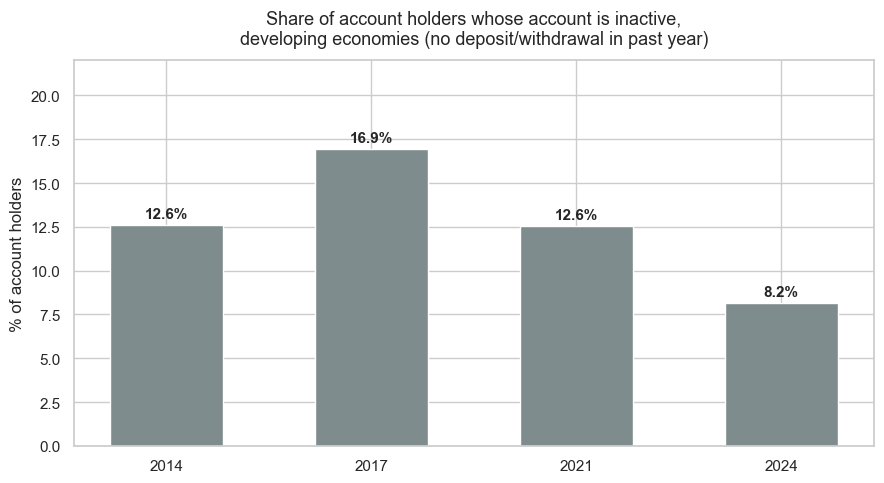

In [15]:
inact = series(pan_dev, 'inactive_t_d', [2014, 2017, 2021, 2024])
acc_dev = series(pan_dev, 'account_t_d', [2014, 2017, 2021, 2024])
ratio = (inact / acc_dev * 100)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ratio.index.astype(str), ratio, width=0.55, color='#7f8c8d')
for b in bars:
    ax.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width() / 2, b.get_height() + 0.4),
                ha='center', fontweight='bold', fontsize=11)
ax.set_title('Share of account holders whose account is inactive,\ndeveloping economies (no deposit/withdrawal in past year)', fontsize=13, pad=12)
ax.set_ylabel('% of account holders')
ax.set_ylim(0, 22)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig7_inactivity.png', bbox_inches='tight')
plt.show()

Dormancy is the quality check on the access story: it spiked to ~17% of account holders in 2017 — right after the largest account-opening drives — and has since fallen to ~8%, meaning newly opened accounts increasingly get used. (Computed as the weighted share of adults with an inactive account divided by the weighted share with any account.)

## 5. Financial resilience

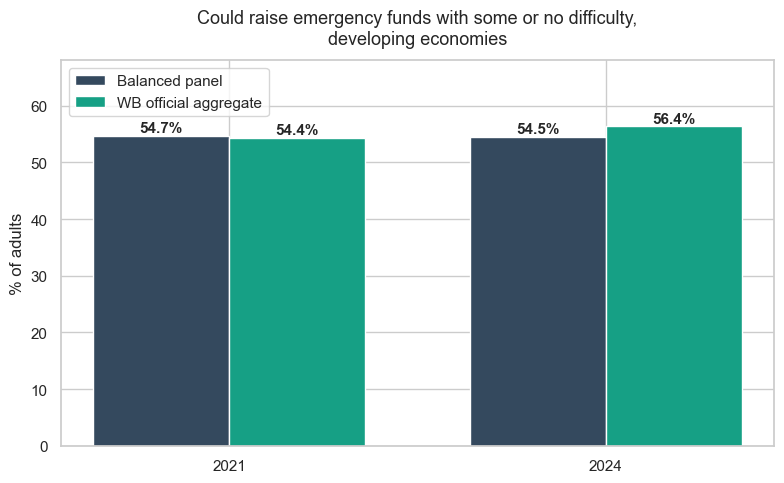

In [16]:
res_panel = series(pan_dev, 'fin24aSD_ND', [2021, 2024])
res_off = official_series('Developing economies', 'fin24aSD_ND', [2021, 2024])

x = np.arange(2)
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - 0.18, res_panel, width=0.36, color='#34495e', label='Balanced panel')
b2 = ax.bar(x + 0.18, res_off, width=0.36, color='#16a085', label='WB official aggregate')
for bars in (b1, b2):
    for b in bars:
        ax.annotate(f'{b.get_height():.1f}%', (b.get_x() + b.get_width() / 2, b.get_height() + 0.6),
                    ha='center', fontweight='bold', fontsize=11)
ax.set_xticks(x, ['2021', '2024'])
ax.set_title('Could raise emergency funds with some or no difficulty,\ndeveloping economies', fontsize=13, pad=12)
ax.set_ylabel('% of adults')
ax.set_ylim(0, 68)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig8_resilience.png', bbox_inches='tight')
plt.show()

Financial resilience in developing economies was **broadly stable between 2021 and 2024** — flat on the balanced panel (54.7% → 54.5%), modestly improving on the official aggregate (54.4% → 56.4%, where the World Bank also imputes economies my panel excludes). Either way, resilience did *not* deteriorate — but it also did not improve anywhere near as fast as access or digital payments. Roughly 45% of adults in developing economies still could not raise emergency funds without serious difficulty in 2024, which keeps the access–resilience gap the central policy problem of financial inclusion.

## 6. Who is still left out

### 6.1 The gender gap

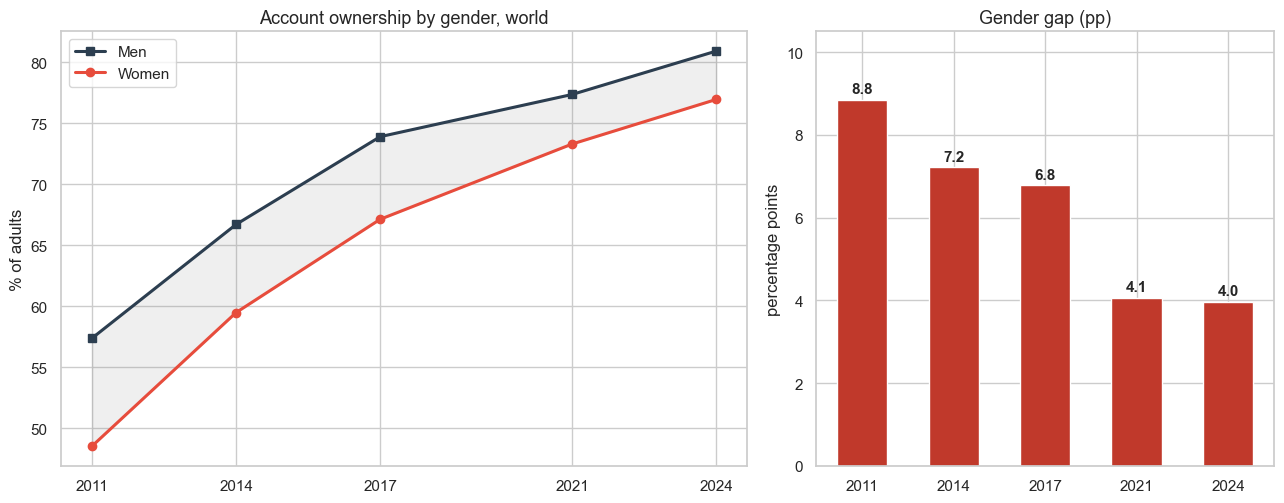

In [17]:
men = series(pan_grp[pan_grp['group2'] == 'men'], 'account_t_d')
women = series(pan_grp[pan_grp['group2'] == 'women'], 'account_t_d')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={'width_ratios': [3, 2]})
ax1.plot(men.index, men, marker='s', lw=2.2, color='#2c3e50', label='Men')
ax1.plot(women.index, women, marker='o', lw=2.2, color='#e74c3c', label='Women')
ax1.fill_between(men.index, men, women, color='gray', alpha=0.12)
ax1.set_title('Account ownership by gender, world', fontsize=13)
ax1.set_ylabel('% of adults')
ax1.set_xticks(YEARS)
ax1.legend()

gap = men - women
ax2.bar(gap.index.astype(str), gap, color='#c0392b', width=0.55)
for x, y in gap.items():
    ax2.annotate(f'{y:.1f}', (str(x), y + 0.15), ha='center', fontweight='bold', fontsize=11)
ax2.set_title('Gender gap (pp)', fontsize=13)
ax2.set_ylabel('percentage points')
ax2.set_ylim(0, 10.5)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig9_gender_gap.png', bbox_inches='tight')
plt.show()

The global gender gap in account ownership **halved over the period — from 8.8 pp in 2011 to 4.0 pp in 2024** — with the sharpest narrowing after 2017, when mobile money and large-scale account programs reached women who had never interacted with a bank. It has not closed: at 2024 rates of change, parity is still years away.

### 6.2 The income gap

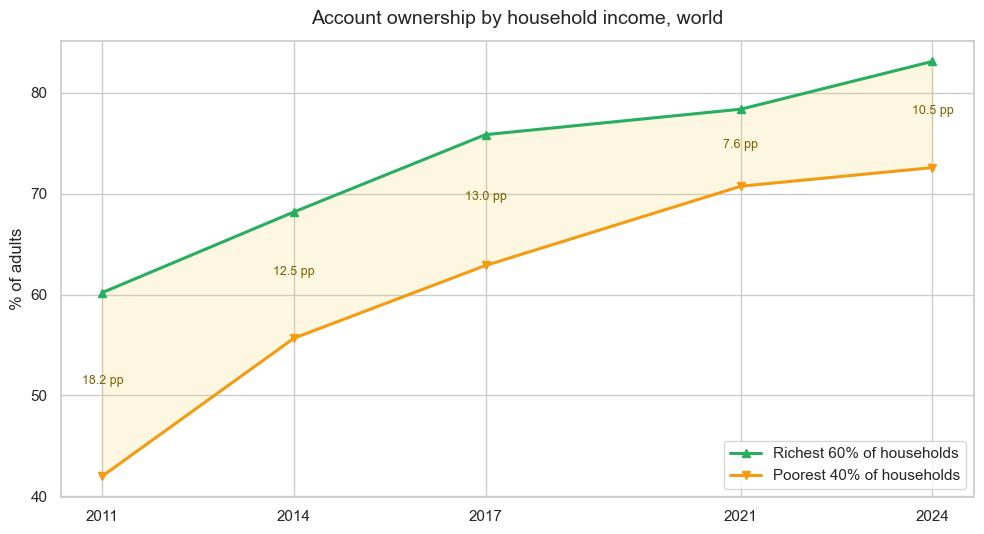

In [18]:
rich = series(pan_grp[pan_grp['group2'] == 'richest 60%'], 'account_t_d')
poor = series(pan_grp[pan_grp['group2'] == 'poorest 40%'], 'account_t_d')

plt.figure(figsize=(10, 5.5))
plt.plot(rich.index, rich, marker='^', lw=2.2, color='#27ae60', label='Richest 60% of households')
plt.plot(poor.index, poor, marker='v', lw=2.2, color='#f39c12', label='Poorest 40% of households')
plt.fill_between(rich.index, rich, poor, color='#f1c40f', alpha=0.12)
for x in YEARS:
    plt.annotate(f'{rich[x] - poor[x]:.1f} pp', (x, (rich[x] + poor[x]) / 2),
                 ha='center', fontsize=9, color='#7f6000')
plt.title('Account ownership by household income, world', fontsize=14, pad=12)
plt.ylabel('% of adults')
plt.xticks(YEARS)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig10_income_gap.png', bbox_inches='tight')
plt.show()

The income gap is consistently **larger than the gender gap** — economic status remains the strongest single predictor of exclusion. It narrowed from 18.2 pp (2011) to 10.5 pp (2024), but not monotonically: the unusually small 2021 gap (7.6 pp) coincides with the COVID-era wave, when emergency government transfers pushed millions of poorer adults into first-time account ownership; part of that convergence receded by 2024.

## 7. Notes on the original analysis

This notebook is a rebuild of the empirical chapter of my bachelor's thesis. Auditing the original code against the World Bank's published aggregates surfaced five substantive errors — all of them variations of two mistakes: *aggregating over rows that should have been filtered* and *letting the country composition change between waves*.

| Original figure | It showed | Corrected result | Root cause |
|---|---|---|---|
| Global mobile money | 29.9% of adults (2024) | **17.0%** (official: 16.0%) | Averaged only economies where mobile money is surveyed; subgroup rows included |
| Financial resilience | declining 57.2% → 52.7% | **flat-to-improving** 54.7% → 54.5% (official: 54.4% → 56.4%) | No population-group filter; high-income economies mixed into a developing-economies indicator; unbalanced composition |
| Formal borrowing | falling 27.0% → 21.3% | **rising** 15.7% → 23.2% | Country mix changed between waves; narrow indicator; global instead of developing scope |
| Formal saving | gentle rise, +4.8 pp | **+13.7 pp surge** — the flagship Findex 2025 finding | Indicator excluded mobile-money saving; global scope diluted the signal |
| Regional digital payments | high-income "collapse" 92% → 72% | **no 2024 data** for 35 of 40 high-income panel economies — line correctly ends in 2021 | Five remaining economies plotted as if they represented the group |

Two engineering lessons did most of the work in this rebuild: **(1)** in a long-format file with disaggregation rows, every aggregate must filter to one `group` slice; **(2)** when a dataset ships with the publisher's own aggregate rows, validating against them should be step one, not an afterthought — it would have caught all five errors immediately.

## 8. Conclusions

**Access is the success story.** Account ownership rose from ~51% of adults in 2011 to ~79% in 2024, with South Asia and Sub-Saharan Africa converging fastest from the lowest bases. Mobile money became the dominant on-ramp in Sub-Saharan Africa (44% of adults).

**Usage finally caught up in the last wave.** Digital payments reached 61% of adults in developing economies, and formal saving — flat for a decade — surged 14–16 pp between 2021 and 2024, largely over mobile-money rails. Borrowing grew slowly and steadily; dormancy declined.

**Resilience is the unfinished agenda.** Stable rather than deteriorating, but stuck near 55%: almost half of adults in developing economies could not comfortably raise emergency funds in 2024. Access expanded much faster than the financial security it was meant to enable.

**Gaps narrowed but persist.** The gender gap halved to 4 pp; the income gap, at 10.5 pp, remains the wider divide.

**Limitations.** Findex is a repeated cross-section of country-level aggregates: it supports trend description, not causal claims. The balanced panel trades a small coverage loss (3.5% of surveyed adult population) for compositional consistency; the World Bank's imputed aggregates differ by up to ~1.5 pp. Wave timing (3–4 year intervals, one wave COVID-delayed) limits short-run interpretation.

---
*Data: Global Findex Database 2025, World Bank (Klapper, Singer, Starita & Norris, 2025). Analysis and any errors: my own.*